<img src="./logo_UTN.svg" align="right" width="150" />  

# Trabajo semanal 3
**Estudiante:**  Beltrame Alejo David  
**Profesor:** Mariano Llamedo Soria  
**Ayudante de TPs:** David Moharos

#### Ejercicio 1: Obtener la transferencia mediante aproximación de Chebyshev del filtro requerido.

##### 1. Parámetros y Normalización Pasa Altos

$$f_p = 40 \text{ kHz}, \quad f_s = 10 \text{ kHz}$$

$$\Omega_s = \frac{f_p}{f_s} = \frac{40 \text{ kHz}}{10 \text{ kHz}} = 4$$


##### 2. Factor de Ripple ($\epsilon$)

$$\epsilon^2 = 10^{\alpha_{max}/10} - 1$$

$$\epsilon^2 = 10^{0.5/10} - 1 = 10^{0.05} - 1 \approx 0.1220$$

$$\epsilon = \sqrt{0.1220} \approx 0.3493$$


##### 3. Iteración del Orden ($n$)

Condición: $\alpha \ge 30 \text{ dB}$


$$\alpha = 10\log_{10}\left(1 + \epsilon^2 \cosh^2(n \cdot \cosh^{-1}(\Omega_s))\right)$$


Sabiendo que $\cosh^{-1}(4) \approx 2.0634$:

* $n = 1 \implies \alpha = 10\log_{10}(1 + 0.122 \cdot \cosh^2(2.0634)) = 4.7 \text{ dB}$
* $n = 2 \implies \alpha = 10\log_{10}(1 + 0.122 \cdot \cosh^2(4.1268)) = 20.7 \text{ dB}$
* $n = 3 \implies \alpha = 10\log_{10}(1 + 0.122 \cdot \cosh^2(6.1902)) = 38.6 \text{ dB} \quad \checkmark$

$$n = 3$$


##### 4. Cálculo de Polos ($p_k = \sigma_k + j\omega_k$)

$$a = \frac{1}{n}\sinh^{-1}\left(\frac{1}{\epsilon}\right) = \frac{1}{3}\sinh^{-1}\left(\frac{1}{0.3493}\right) \approx 0.5914$$

$$\sinh(a) = 0.6265, \quad \cosh(a) = 1.1800$$

Ángulo $\theta_k = \frac{(2k-1)\pi}{2n} = \frac{(2k-1)\pi}{6}$:

* **k = 1** ($\theta_1 = 30^\circ$):

$$p_1 = -0.6265\sin(30^\circ) + j1.1800\cos(30^\circ) = -0.3132 + j1.0219$$


* **k = 2** ($\theta_2 = 90^\circ$):

$$p_2 = -0.6265\sin(90^\circ) + j1.1800\cos(90^\circ) = -0.6265$$


* **k = 3** ($\theta_3 = 150^\circ$):

$$p_3 = -0.6265\sin(150^\circ) + j1.1800\cos(150^\circ) = -0.3132 - j1.0219$$


##### 5. Transferencia del Prototipo Pasa Bajos ($H_{LPP}$)

$$H_{LPP}(S) = \frac{K}{(S - p_1)(S - p_2)(S - p_3)}$$

$$(S - p_1)(S - p_3) = (S + 0.3132)^2 + (1.0219)^2 = S^2 + 0.6264S + 1.1424$$

$$Denominador = (S + 0.6265)(S^2 + 0.6264S + 1.1424)$$

Para $n=3$ (impar), la ganancia en DC es 1. El numerador $K$ es el producto de los términos independientes:


$$K = 0.6265 \cdot 1.1424 = 0.7157$$

$$H_{LPP}(S) = \frac{0.7157}{(S + 0.6265)(S^2 + 0.6264S + 1.1424)}$$


##### 6. Transferencia del Filtro Pasa Altos ($H(s)$)

Transformación de frecuencia: $S = \frac{\omega_p}{s}$ con $\omega_p = 2\pi(40\times 10^3) = 80000\pi \text{ rad/s}$

$$H(s) = H_{LPP}\left(\frac{\omega_p}{s}\right)$$

$$H(s) = \frac{0.7157}{\left(\frac{\omega_p}{s} + 0.6265\right)\left(\left(\frac{\omega_p}{s}\right)^2 + 0.6264\left(\frac{\omega_p}{s}\right) + 1.1424\right)}$$

Acondicionando la ecuación (multiplicando numerador y denominador por $s^3$ y normalizando coeficientes):


$$H(s) = \left( \frac{s}{s + \frac{\omega_p}{0.6265}} \right) \cdot \left( \frac{s^2}{s^2 + \frac{0.6264}{1.1424}\omega_p s + \frac{1}{1.1424}\omega_p^2} \right)$$

$$H(s) = \left( \frac{s}{s + 1.5962\omega_p} \right) \cdot \left( \frac{s^2}{s^2 + 0.5483\omega_p s + 0.8753\omega_p^2} \right)$$

#### Ejercicio 2: Obtener la respuesta en frecuencia (módulo y fase) de forma cualitativa. Compare además el pzmap con el del filtro pasabajo prototipo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

# Librería de TC2
from pytc2.sistemas_lineales import pzmap, bodePlot
from pytc2.general import print_latex, a_equal_b_latex_s, s

In [2]:
fp = 40000                  # Frecuencia de corte en Hz
wp = 2 * np.pi * fp         # Frecuencia de corte angular (rad/s)

In [3]:
# PROTOTIPO PASA BAJOS (LPP) NORMALIZADO
num_lpp = np.array([0.7157])
den_lpp = np.array([1, 1.2529, 1.5367, 0.7157])
tf_lpp = sig.TransferFunction(num_lpp, den_lpp)

In [4]:
# FILTROS PASA ALTOS (NORMALIZADO Y DES-NORMALIZADO)
# A) Versión Des-normalizada (Para el Diagrama de Bode)
num_hpf_real, den_hpf_real = sig.lp2hp(num_lpp, den_lpp, wo=wp)
tf_hpf_real = sig.TransferFunction(num_hpf_real, den_hpf_real)

# B) Versión Normalizada (Para comparar Polos y Ceros)
num_hpf_norm, den_hpf_norm = sig.lp2hp(num_lpp, den_lpp, wo=1)
tf_hpf_norm = sig.TransferFunction(num_hpf_norm, den_hpf_norm)

In [5]:
# IMPRESIÓN LaTeX
polo_real = 1.5962 * wp
coef_s = 0.5483 * wp
coef_s0 = 0.8753 * (wp**2)

T_hpf_sym = (s**3) / ((s + polo_real) * (s**2 + coef_s*s + coef_s0))
print_latex(a_equal_b_latex_s('H_{HPF}(s)', T_hpf_sym))

<IPython.core.display.Math object>

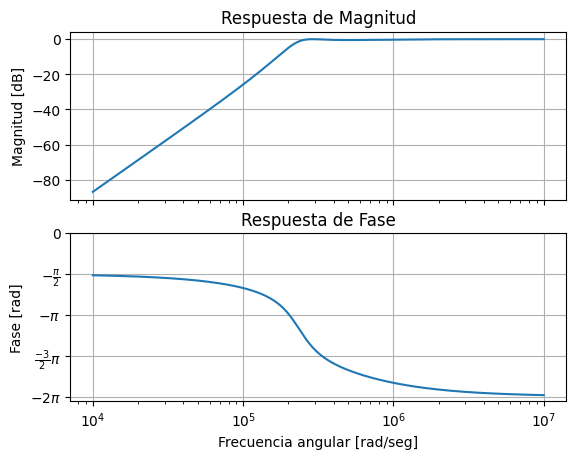

In [7]:
# Gráfico 1: Diagrama de Bode (Módulo y Fase) del Pasa Altos REAL (40 kHz)
bodePlot(tf_hpf_real, fig_id=1);

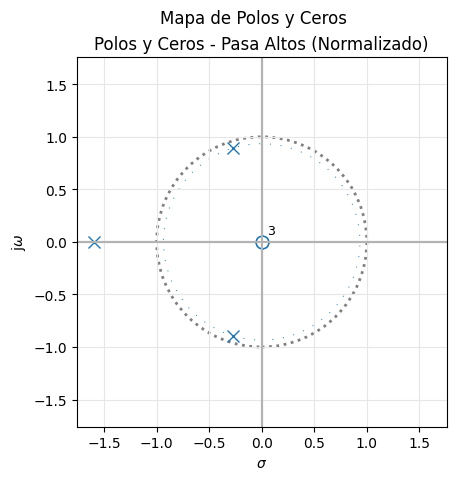

In [10]:
# Gráfico 2: Diagrama de Polos y Ceros del Pasa Altos NORMALIZADO
pzmap(tf_hpf_norm, fig_id=2)
plt.figure(2)
plt.title("Polos y Ceros - Pasa Altos (Normalizado)");

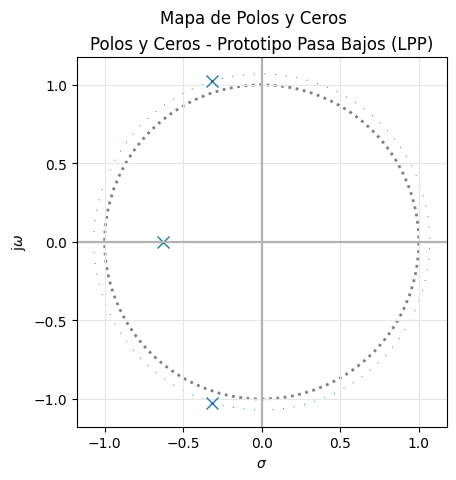

In [11]:
# Gráfico 3: Diagrama de Polos y Ceros del Prototipo Pasa Bajos NORMALIZADO
pzmap(tf_lpp, fig_id=3)
plt.figure(3)
plt.title("Polos y Ceros - Prototipo Pasa Bajos (LPP)");

##### Efecto de la Transformación S = 1/s en Polos y Ceros

Al transformar el prototipo pasa bajos en un filtro pasa altos, se pueden ver los siguientes cambios:  

* Aparición de ceros en el origen: El prototipo pasa bajos no tiene ceros visibles (están en el infinito). La transformación trae esos tres ceros directamente al origen ($s=0$) del pasa altos, lo que garantiza el bloqueo total de la corriente continua.
* Inversión radial (Adentro/Afuera): Como la nueva magnitud es la inversa de la original ($|s| = 1/|S|$), ocurre un efecto "espejo" respecto a la circunferencia de radio 1. El polo real que estaba adentro de la circunferencia es expulsado hacia afuera, mientras que los polos complejos que estaban apenas afuera, ahora ingresan.
* Aplastamiento de la elipse: Los polos del prototipo de Chebyshev se ubican sobre una elipse perfectamente vertical (paralela al eje imaginario). Al aplicar la inversa, esa geometría se invierte y colapsa, pasando a estar fuertemente estirada hacia los costados sobre el eje real.
* Intercambio de distancias: En el pasa bajos, los polos complejos están más lejos del origen que el polo real. En el pasa altos, estas distancias se invierten por completo: los complejos quedan recluidos cerca del origen y el polo real es empujado lejos en el eje negativo.

#### Ejercicio 3: Implementar el circuito normalizado con estructuras pasivas utilizando dispositivos activos para separar secciones. 

![Filtro Pasa Altos de 3er Orden Pasivo](FiltroHPPas.png)

##### 1. Normalización de Resistencias

Para trabajar con el prototipo normalizado en frecuencia y magnitud, fijamos:


$$R_1 = 1\,\Omega, \quad R_L = 1\,\Omega$$


##### 2. Desarrollo de la Etapa de 1er Orden

Filtro RC pasa altos pasivo conectado a la entrada no inversora del Op-Amp (Buffer):

$$H_1(s) = \frac{V_1(s)}{V_i(s)} = \frac{R_1}{R_1 + \frac{1}{sC_1}} = \frac{sR_1C_1}{sR_1C_1 + 1} = \frac{s}{s + \frac{1}{R_1C_1}}$$

Sustituyendo $R_1 = 1\,\Omega$:


$$H_1(s) = \frac{s}{s + \frac{1}{C_1}}$$

Fijación de $C_1$ para el polo $s_2$

El polo real calculado para el pasa altos de Chebyshev es $s_2 = -1.5962$. Igualando el término independiente del denominador:


$$\frac{1}{C_1} = 1.5962 \implies C_1 = \frac{1}{1.5962} \approx 0.6265\text{ F}$$


##### 3. Desarrollo de la Etapa de 2do Orden

Filtro CLR pasa altos pasivo conectado a la salida del Buffer. La impedancia de carga en paralelo es la combinación del inductor $L$ y la resistencia $R_L$:

$$Z_p(s) = Ls \parallel R_L = \frac{sL \cdot R_L}{sL + R_L}$$

Aplicando divisor de tensión entre el capacitor $C_2$ y la impedancia en paralelo $Z_p(s)$:


$$H_2(s) = \frac{V_o(s)}{V_1(s)} = \frac{Z_p(s)}{\frac{1}{sC_2} + Z_p(s)} = \frac{\frac{sL R_L}{sL + R_L}}{\frac{1}{sC_2} + \frac{sL R_L}{sL + R_L}}$$

Multiplicando numerador y denominador por $sC_2(sL + R_L)$:


$$H_2(s) = \frac{s^2 L C_2 R_L}{sL + R_L + s^2 L C_2 R_L} = \frac{s^2 L C_2 R_L}{s^2 L C_2 R_L + sL + R_L}$$

Dividiendo todo por el coeficiente principal $L C_2 R_L$:


$$H_2(s) = \frac{s^2}{s^2 + \frac{1}{R_L C_2}s + \frac{1}{L C_2}}$$

Sustituyendo $R_L = 1\,\Omega$:


$$H_2(s) = \frac{s^2}{s^2 + \frac{1}{C_2}s + \frac{1}{L C_2}}$$


##### 4. Determinación de Componentes de 2do Orden

El polinomio objetivo de segundo orden para este filtro pasa altos de Chebyshev es:


$$s^2 + 0.5484s + 0.8753$$

Fijación de $C_2$ para la parte real (amortiguamiento)

Igualamos el coeficiente del término lineal ($s^1$):


$$\frac{1}{C_2} = 0.5484 \implies C_2 = \frac{1}{0.5484} \approx 1.8235\text{ F}$$

Fijación de $L$ para obtener el $\omega_0^2$ deseado

Igualamos el término independiente del polinomio ($s^0$), el cual representa la frecuencia de resonancia al cuadrado ($\omega_0^2 = 0.8753$):


$$\frac{1}{L C_2} = 0.8753$$

Despejando $L$ con el valor de $C_2$ ya calculado:


$$L = \frac{1}{0.8753 \cdot C_2} = \frac{1}{0.8753 \cdot 1.8235} = \frac{1}{1.5961} \approx 0.6265\text{ H}$$


##### 5. Resumen de Valores Normalizados finales

* **$R_1 = 1\,\Omega$**
* **$R_L = 1\,\Omega$**
* **$C_1 = 0.6265\text{ F}$**
* **$C_2 = 1.8235\text{ F}$**
* **$L = 0.6265\text{ H}$**

#### Ejercicio 4: Reemplace los inductores en las estructuras pasivas mediante el GIC de Antoniou, en la configuración que considere más apropiada.

![Filtro Pasa Altos de 3er Orden Pasivo con GIC](FiltroHPGIC.png)

##### Valores del Filtro Pasivo (Obtenidos previamente)
* $R_1 = 1\,\Omega$
* $R_2 = 1\,\Omega$
* $C_1 = 0.6265\text{ F}$
* $C_2 = 1.8235\text{ F}$
* $L_{eq} = 0.6265\text{ H}$


##### Normalización del GIC
Fijamos todas las resistencias del bloque de Antoniou a la unidad:
$$R_3 = R_4 = R_5 = R_6 = 1\,\Omega$$


##### Desarrollo y Cálculo de $C_3$
La impedancia de entrada del GIC con el capacitor en la segunda posición simula una inductancia pura conectada a tierra. La ecuación general es:
$$L_{eq} = \frac{C_3 \cdot R_3 \cdot R_4 \cdot R_6}{R_5}$$

Sustituyendo las resistencias por sus valores normalizados ($1\,\Omega$) y el valor de inductancia requerido ($0.6265\text{ H}$):
$$0.6265 = \frac{C_3 \cdot (1) \cdot (1) \cdot (1)}{1}$$

Despejando el capacitor:
$$C_3 = 0.6265\text{ F}$$


##### Resumen de Componentes Normalizados
* Resistencias: $R_1 = R_2 = R_3 = R_4 = R_5 = R_6 = 1\,\Omega$
* Capacitores: $C_1 = 0.6265\text{ F}, \quad C_2 = 1.8235\text{ F}, \quad C_3 = 0.6265\text{ F}$

#### Ejercicio 5: Reemplace la SOS pasiva del punto 3. por la estructura MFB en configuración pasa altos y realice el estudio de sensibilidad de $S_{\omega_0}^{C_1}$, $S_Q^{R_1}$ y $S_Q^{R_2}$.

![Filtro Pasa Altos de 3er Orden MFB](FiltroHPMFB.png)

##### Etapa Pasiva de 1er Orden
Los valores permanecen inalterados dado el aislamiento que proporciona el buffer (U2):
* $R_1 = 1\,\Omega$
* $C_1 = 0.6265\text{ F}$


##### Desarrollo Analítico de la Etapa MFB Pasa Altos
Se plantea el análisis de nodos utilizando admitancias ($Y = sC$ para capacitores y $Y = \frac{1}{R}$ para resistencias).

Nodo $V_x$ (Centro de la red capacitiva):
La suma de corrientes es nula:
$$V_x (Y_{C2} + Y_{C3} + Y_{C4} + Y_{R3}) = V_i Y_{C3} + V_o Y_{C4}$$

Nodo $V^-$ (Entrada inversora de U1):
Considerando masa virtual ($V^- = 0$):
$$V_x Y_{C2} + V_o Y_{R2} = 0 \implies V_x = -V_o \frac{Y_{R2}}{Y_{C2}}$$

Sustitución y Función de Transferencia:
Reemplazando $V_x$ en la primera ecuación:
$$\left(-V_o \frac{Y_{R2}}{Y_{C2}}\right) (Y_{C2} + Y_{C3} + Y_{C4} + Y_{R3}) = V_i Y_{C3} + V_o Y_{C4}$$

Agrupando términos dependientes de $V_o$:
$$-V_o \left[ \frac{Y_{R2}}{Y_{C2}} (Y_{C2} + Y_{C3} + Y_{C4} + Y_{R3}) + Y_{C4} \right] = V_i Y_{C3}$$

Multiplicando por $Y_{C2}$ para despejar denominadores internos:
$$-V_o [ Y_{R2} (Y_{C2} + Y_{C3} + Y_{C4} + Y_{R3}) + Y_{C2} Y_{C4} ] = V_i Y_{C2} Y_{C3}$$

Despejando la relación $\frac{V_o}{V_i}$:
$$H(s) = \frac{-Y_{C2} Y_{C3}}{Y_{C2} Y_{C4} + Y_{R2} (Y_{C2} + Y_{C3} + Y_{C4} + Y_{R3})}$$

Sustituyendo admitancias ($sC$ y $\frac{1}{R}$) y dividiendo por $C_2 C_4$ para normalizar el coeficiente de $s^2$:
$$H(s) = \frac{-s^2 \frac{C_3}{C_4}}{s^2 + s \frac{C_2 + C_3 + C_4}{R_2 C_2 C_4} + \frac{1}{R_2 R_3 C_2 C_4}}$$


##### Síntesis y Normalización MFB
Se fija $C_2 = C_3 = C_4 = 1\text{ F}$ (No se normalizan las resistencias ya que esto conduce a valores capacitivos negativos, lo cual carece de sentido físico). 

Aplicando la normalización capacitiva, el denominador se reduce a:
$$s^2 + s \frac{3}{R_2} + \frac{1}{R_2 R_3}$$

Igualando con el polinomio objetivo de Chebyshev ($s^2 + 0.5484s + 0.8753$):

1. Cálculo de $R_2$ (Coeficiente lineal):
   $$\frac{3}{R_2} = 0.5484 \implies R_2 = \frac{3}{0.5484} \approx 5.4705\,\Omega$$

2. Cálculo de $R_3$ (Término independiente):
   $$\frac{1}{R_2 R_3} = 0.8753 \implies R_3 = \frac{1}{0.8753 \cdot R_2} \approx 0.2089\,\Omega$$

##### Definición de Parámetros y Función de Sensibilidad
Partiendo del denominador de la transferencia de la celda MFB y comparando con la forma canónica $s^2 + s\frac{\omega_0}{Q} + \omega_0^2$, se identifican los siguientes parámetros:

$$\omega_0 = \frac{1}{\sqrt{R_2 R_3 C_2 C_4}}$$
$$Q = \frac{\omega_0}{\frac{C_2 + C_3 + C_4}{R_2 C_2 C_4}} = \sqrt{\frac{R_2}{R_3}} \frac{\sqrt{C_2 C_4}}{C_2 + C_3 + C_4}$$

La sensibilidad relativa de un parámetro $Y$ respecto a la variación de un componente $X$ se define mediante la expresión:
$$S_X^Y = \frac{\partial Y}{\partial X} \frac{X}{Y}$$

Aplicando la propiedad de sensibilidad para funciones conformadas por productos y potencias, se establece que si $Y = k \cdot X^n$, entonces $S_X^Y = n$.


##### Sensibilidad de $\omega_0$ respecto a $C_4$ ($S_{C_4}^{\omega_0}$)
Expresando $\omega_0$ y aislando el término correspondiente al capacitor $C_4$:
$$\omega_0 = (R_2 R_3 C_2)^{-1/2} \cdot C_4^{-1/2}$$

Extrayendo el exponente según la propiedad definida:
$$S_{C_4}^{\omega_0} = -\frac{1}{2}$$


##### Sensibilidad de $Q$ respecto a $R_3$ ($S_{R_3}^Q$)
Expresando el factor de calidad $Q$ y aislando el término de la resistencia $R_3$:
$$Q = \left[ \sqrt{R_2} \frac{\sqrt{C_2 C_4}}{C_2 + C_3 + C_4} \right] \cdot R_3^{-1/2}$$

Reemplazando y extrayendo el exponente:
$$S_{R_3}^Q = -\frac{1}{2}$$


##### Sensibilidad de $Q$ respecto a $R_2$ ($S_{R_2}^Q$)
Expresando el factor de calidad $Q$ y aislando el término de la resistencia $R_2$:
$$Q = \left[ \frac{1}{\sqrt{R_3}} \frac{\sqrt{C_2 C_4}}{C_2 + C_3 + C_4} \right] \cdot R_2^{1/2}$$

Reemplazando y extrayendo el exponente:
$$S_{R_2}^Q = \frac{1}{2}$$

#### Ejercicio 6: En todos los casos, verifique el requerimiento de la plantilla en LTSpice mediante el uso de cursores.

##### Circuito pasivo:  
Diagrama:

![Circuito LTSpice Pasivo](FiltroHPPasLTC.png)

Graficos:

![Grafico filtro pasivo](FiltroHPPasLTG1.png)

![Grafico filtro pasivo](FiltroHPPasLTG2.png)

##### Ajuste del Modelo Ideal del Inductor en Simulación 
Para evaluar la respuesta matemática ideal del filtro pasivo, fue necesario modificar la resistencia parásita en serie de la bobina ($R_{ser}$) a un valor muy cercano a $0\,\Omega$, anulando el valor de $1\text{ m}\Omega$ que LTSpice asigna por defecto. Este ajuste sirve para asegurar que la fase inicie correctamente en $-90^\circ$ a muy bajas frecuencias y garantizando que la magnitud alcance exactamente los $0\text{ dB}$ en las crestas del rizado.

##### Circuito con GIC:
Diagrama:

![Circuito LTSpice GIC](FiltroHPGICC.png)

Graficos:
![Grafico filtro GIC](FiltroHPGICG1.png)
![Grafico filtro GIC](FiltroHPGICG2.png)

##### Circuito MFB:  
Diagrama:  
![Circuito LTSpice MFB](FiltroHPMFBC.png)  
Graficos:  
![Grafico filtro MFB](FiltroHPMFBG1.png)
![Grafico filtro MFB](FiltroHPMFBG2.png)

##### Verificación de la Plantilla en la Simulación Normalizada

Para validar los tres circuitos diseñados mediante el simulador LTSpice, se realiza la conversión de las frecuencias angulares normalizadas ($\omega$) a frecuencias lineales en Hertz ($f$), utilizando la relación fundamental:
$$f = \frac{\omega}{2\pi}$$

A continuación se detallan los cálculos analíticos de los puntos de control y los niveles de magnitud en decibelios (dB) esperados en la escala del simulador.


##### Frecuencia de Paso Normalizada ($f_{p\_norm}$)
En el diseño normalizado, la frecuencia angular de paso se fija estructuralmente en la unidad:
$$\omega_p = 1\text{ rad/s}$$

Reemplazando en la fórmula de conversión de frecuencia:
$$f_{p\_norm} = \frac{1\text{ rad/s}}{2\pi} \approx 0.159155\text{ Hz} = 159.155\text{ mHz}$$

* **Magnitud esperada:** **$-0.5\text{ dB}$**
* **Justificación:** Al haberse adoptado una aproximación de Chebyshev con un rizado (ripple) de $0.5\text{ dB}$, la banda de paso oscila entre $0\text{ dB}$ y $-0.5\text{ dB}$. La frecuencia de corte marca el límite exacto donde la atenuación alcanza los $-0.5\text{ dB}$ antes de ingresar a la banda de transición.


##### Frecuencia de Rechazo Normalizada ($f_{s\_norm}$)
Partiendo de los requerimientos de la plantilla original en frecuencias reales ($f_p = 40\text{ kHz}$ y $f_s = 10\text{ kHz}$), se establece la relación de normalización para un filtro pasa altos:
$$\omega_s = \frac{f_s}{f_p} = \frac{10\text{ kHz}}{40\text{ kHz}} = 0.25\text{ rad/s}$$

Efectuando la conversión a la escala de frecuencias de LTSpice:
$$f_{s\_norm} = \frac{0.25\text{ rad/s}}{2\pi} \approx 0.039789\text{ Hz} = 39.789\text{ mHz}$$

* **Magnitud esperada:** **$\le -30\text{ dB}$**  
* **Justificación:** La plantilla exige una atenuación mínima de $30\text{ dB}$ en la banda de rechazo. Debido al margen de seguridad que proporciona el polinomio de Chebyshev de 3er orden ($n=3$), la atenuación obtenida en el simulador se sitúa casi $10\text{ dB}$ por debajo del mínimo exigido, garantizando el cumplimiento estricto del requerimiento.

##### Conclusión de Simulación

Analizando las mediciones arrojadas por los cursores en las simulaciones de LTSpice, se comprueba que los tres circuitos implementados (Pasivo, Activo GIC y Activo MFB) cumplen rigurosamente con la plantilla de diseño solicitada.

* **Banda de paso:** Se verifica el comportamiento propio de la aproximación de Chebyshev, respetando el rizado máximo admitido y registrando una caída exacta de 0.5 dB en la frecuencia de corte normalizada ($f_p$).
* **Banda de rechazo:** Se corrobora una atenuación superior a los 30 dB exigidos en la frecuencia de rechazo normalizada ($f_s$), validando la elección de un filtro de tercer orden ($n=3$).

En consecuencia, se da por validado el desarrollo matemático y el diseño esquemático de las tres topologías propuestas.

#### Bonus 1: ¿Podría implementar una red del mismo orden con una aproximación de máxima planicidad?

##### Evaluación: Butterworth de 3er Orden vs. Plantilla

**Parámetros normalizados:**
* Orden del filtro: $n = 3$
* Frecuencia de rechazo ($\Omega_s$): $\frac{40\text{ kHz}}{10\text{ kHz}} = 4$
* Exigencia banda de paso ($\alpha_{max}$): $0.5\text{ dB}$
* Exigencia banda de rechazo ($\alpha_{min}$): $\ge 30\text{ dB}$

**Atenuación alcanzada en $\Omega_s$ (Aproximación Butterworth):**
$$\alpha(\Omega_s) = 10 \log_{10}(1 + \epsilon^2 \Omega_s^{2n})$$
$$\alpha(4) = 10 \log_{10}(1 + 0.122 \cdot 4^6)$$
$$\alpha(4) = 10 \log_{10}(1 + 0.122 \cdot 4096)$$
$$\alpha(4) \approx 26.99\text{ dB}$$

**Conclusión:**
$$26.99\text{ dB} \not\ge 30\text{ dB}$$

Una red de máxima planicidad (Butterworth) de 3er orden no alcanza la atenuación requerida.

#### Bonus 2: Verifique que el orden obtenido analíticamente, mediante simulación numérica en Python, cumple con el requerimiento de la plantilla.

In [2]:
import sympy as sp

In [9]:
# Definimos 'n' como símbolo, real y positivo
n = sp.symbols('n', real=True, positive=True)

# Definimos nuestros datos numéricos directamente
a_max = 0.5
a_min = 30
Ws = 4

# Calculamos epsilon cuadrado numéricamente
eps_sq = 10**(a_max / 10) - 1

# Armamos la ecuación
ecuacion = sp.Eq(a_min, 10 * sp.log(1 + eps_sq * sp.cosh(n * sp.acosh(Ws))**2, 10))

# Despejamos n de la ecuacion
soluciones = sp.solve(ecuacion, n)

# Tomamos la única solución real que sobrevivió al filtro
n_exacto = soluciones[0].evalf(5)
n_adoptado = sp.ceiling(n_exacto)

print(f"Orden calculado exacto: n = {n_exacto}")
print(f"Orden adoptado: n = {n_adoptado}")

Orden calculado exacto: n = 2.5192
Orden adoptado: n = 3
